# Titanic Survival Statistical Analysis

In this part of the project we will look at some of the characteristics passengers have and how it effected their chance of survival. We will also first test the statistical significance of the characteristic, and if the data is significant will visually represent what we observed from the data

In [24]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from parametric_hypothesis_testing import *

data = pd.read_csv("data/titanic.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Comparing the male to the female survival rate

We will test if there is statistically significant dependence on gender, using the z-test

H0: Survival rate of men >= survival rate of women

Ha: Survival rate of men < survival rate of women

In [25]:
male = data[data["Sex"]=="male"]
female = data[data["Sex"]== "female"]

z_test_2samples (
    male["Survived"],
    female["Survived"],
    np.std(male["Survived"],ddof=1),
    np.std(female["Survived"],ddof=1),
    alternative='less',
    conf_level = 0.95
)

Two-sample Z test (σ known)
Test statistic: -18.6718
p-value:        4.196e-78
Confidence interval: (-0.6112, -0.4951)


{'statistic': np.float64(-18.67183317725917),
 'pvalue': np.float64(4.1961080978310424e-78),
 'ci': (np.float64(-0.6111915911099894), np.float64(-0.4950685508498511))}

From the test by looking at the p-value: 4.196e-78, we can conclude that you had a bigger chance of survival as a women, we can clearly see this by looking at the mean of the survival rates for males and females in the barplot below

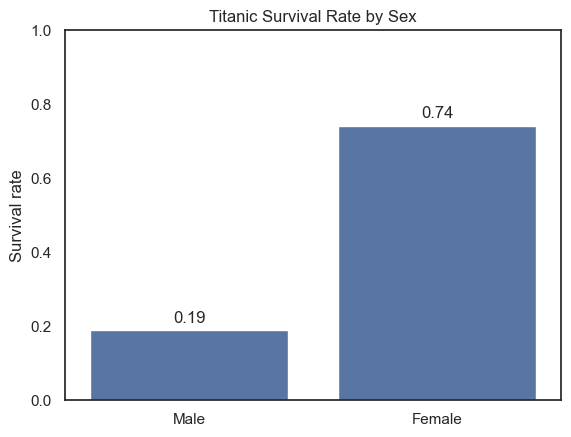

In [26]:
fig, ax = plt.subplots()
sns.set_theme(style="white")

labels = ["Male", "Female"]
survival_rates = [
    male["Survived"].mean(),
    female["Survived"].mean()
]

sns.barplot(x = labels, y = survival_rates, ax = ax, errorbar = None)

ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival Rate by Sex")
ax.text(0, male["Survived"].mean()+0.02, f"{male["Survived"].mean():.2f}", ha="center")
ax.text(1, female["Survived"].mean()+0.02, f"{female["Survived"].mean():.2f}", ha="center")

plt.show()

# Comparing the survival rate of different age groups

We will test if there is statistically significant dependence on age, using the chi-square test

H0: Survival is independent of age group

Ha: Survival depends on age group

In [27]:
age_data = data.dropna(subset = ["Age"])
smallChildren = age_data[age_data["Age"] <= 5]
children = age_data[(age_data["Age"] > 5) & (age_data["Age"] <= 18)]
youngAdult = age_data[(age_data["Age"] > 18) & (age_data["Age"] <= 26)]
adult = age_data[(age_data["Age"] > 26) & (age_data["Age"] <= 60)]
elderly = age_data[age_data["Age"] > 60]

labels = ["Small children", "Children", "Young adult", "Adult", "Elderly"]

survival_rates = [
    smallChildren["Survived"].mean(),
    children["Survived"].mean(),
    youngAdult["Survived"].mean(),
    adult["Survived"].mean(),
    elderly["Survived"].mean()
]

data["AgeGroup"] = pd.cut(age_data["Age"], bins = [0, 5, 18, 26, 60, 100], labels=labels)

table = pd.crosstab(data["AgeGroup"], data["Survived"])


chi2, p, dof, expected = chi2_contingency(table)

We get p = 0.00011219891528134224, p < 0.05 meaning we can say that H0 is not correct and survival depends on age, we can clearly see this by looking at the survival rates by age group in the barplot below

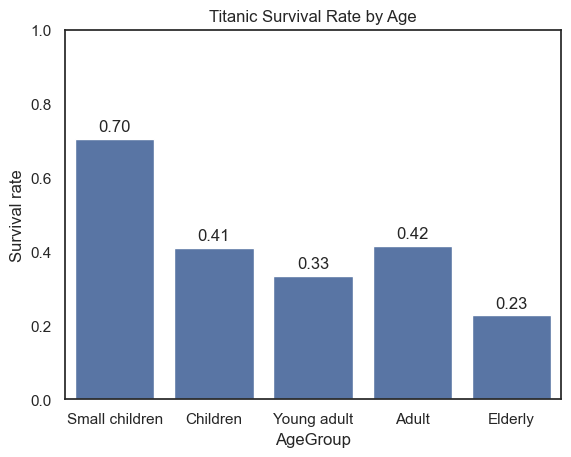

In [28]:
fig, ax = plt.subplots()
sns.set_theme(style="white")

sns.barplot(data = table, x = data["AgeGroup"], y = data["Survived"], ax = ax, errorbar=None)

ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival Rate by Age")

percentages = table.div(table.sum(axis=1), axis=0)[1]
for i, v in enumerate(percentages):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.show()


# Comparing the survival rate of different No. of siblings / spouses aboard the Titanic

We will test if there is statistically significant dependence of No. of siblings / spouses, using the chi-square test

H0: Survival is independent of No. of siblings / spouses

Ha: Survival depends on No. of siblings / spouses

In [29]:
labels = ["0", "1-2", "3-4","5-8"]
bins = [-0.5, 0.5, 2.5, 4.5, 8.5]

data["SibSpGroup"] = pd.cut(data["SibSp"], bins = bins, labels = labels)

table = pd.crosstab(data["SibSpGroup"], data["Survived"])
chi2, p, dof, expected = chi2_contingency(table)


 We get p = 5.9050699295674066e-08, p < 0.05 meaning we can say that H0 is not correct and survival depends on No. of siblings / spouses, we can clearly see this by looking at the survival rates by age group in the barplot below

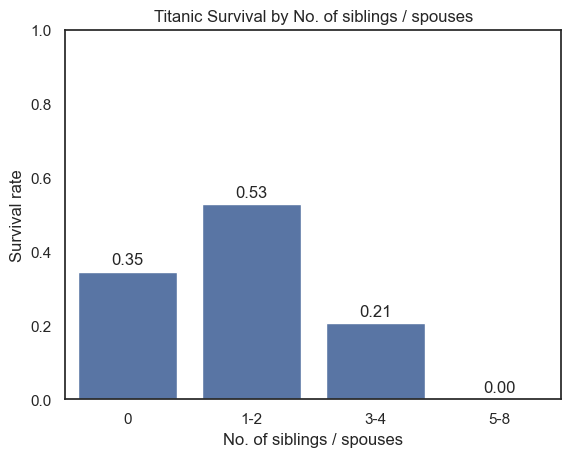

In [30]:
fig,ax = plt.subplots()
sns.set_theme(style="white")

sns.barplot(data = table, x = data["SibSpGroup"], y = data["Survived"], ax = ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival by No. of siblings / spouses")
ax.set_xlabel("No. of siblings / spouses")

percentages = table.div(table.sum(axis=1), axis=0)[1]

for i, v in enumerate(percentages):
    ax.text(i, v + 0.02, f"{v:0.2f}", ha="center")

plt.show()

# Comparing the survival rate of different No. of parents / children aboard the Titanic

We will test if there is statistically significant dependence of No. of parents / children, using the chi-square test

H0: Survival is independent of No. of parents / children

Ha: Survival depends on No. of parents / children

In [31]:
labels = ["0", "1", "2-3","4-6"]
bins = [-0.5, 0.5, 1.5, 3.5, 6.5]

data["ParchGroup"] = pd.cut(data["Parch"], bins = bins, labels = labels)

table = pd.crosstab(data["ParchGroup"], data["Survived"])
chi2, p, dof, expected = chi2_contingency(table)

We get p = 5.083693915431411e-06, p < 0.05 meaning we can say that H0 is not correct and survival depends on No. of siblings / spouses, we can clearly see this by looking at the survival rates by age group in the barplot below

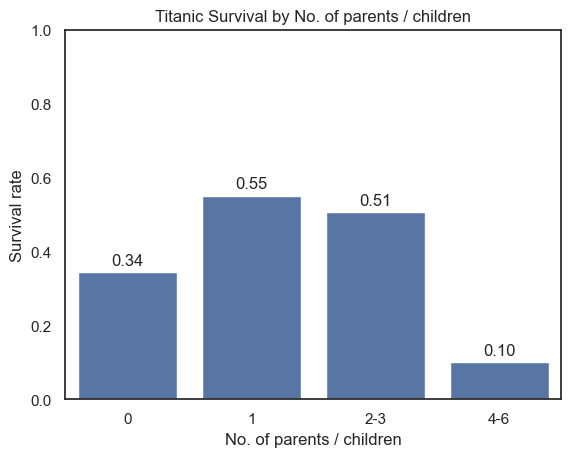

In [32]:
fig,ax = plt.subplots()
sns.set_theme(style="white")

sns.barplot(data = table, x = data["ParchGroup"], y = data["Survived"], ax = ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival by No. of parents / children")
ax.set_xlabel("No. of parents / children")

percentages = table.div(table.sum(axis=1), axis=0)[1]

for i, v in enumerate(percentages):
    ax.text(i, v + 0.02, f"{v:0.2f}", ha="center")

plt.show()

# Comparing the survival rate of different family sizes

We will test if there is statistically significant dependence of family size

H0: Survival is independent of family size

Ha: Survival depends on family size

In [33]:
labels = ["alone","smallFamily","largeFamily"]
bins = [0, 1.5 , 4.5 ,11.5]

data["FamilySize"] = pd.cut(data["Parch"]+data["SibSp"]+1, bins = bins, labels = labels)

table = pd.crosstab(data["FamilySize"], data["Survived"])
chi2, p, dof, expected = chi2_contingency(table)

We get p = 6.522919536640473e-17, p < 0.05 meaning we can say that H0 is not correct and survival depends on No. of siblings / spouses, we can clearly see this by looking at the survival rates by age group in the barplot below

# Comparing the survival rate of ticket classes

We will test if there is statistically significant dependence on ticket class, using the chi-square test

H0: Survival is independent of ticket class

Ha: Survival depends on ticket class


In [34]:
table = pd.crosstab(data["Pclass"],data["Survived"])
chi2, p, dof, expected = chi2_contingency(table)

We get p = 4.549251711298793e-23, p < 0.05 meaning we can say that H0 is not correct and survival depends on ticket class, we can clearly see this by looking at the survival rates by age group in the barplot below

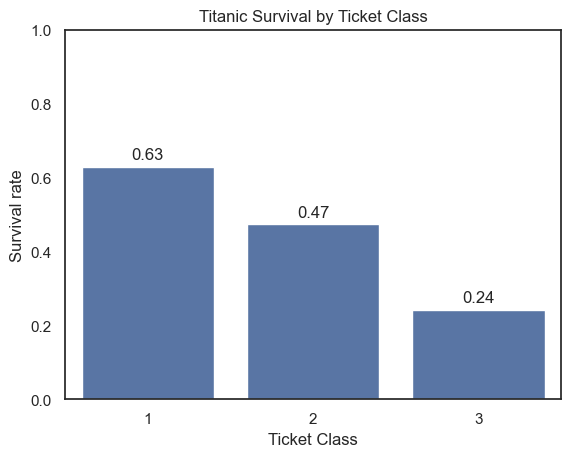

In [35]:
fig, ax = plt.subplots()
sns.set_theme(style="white")

sns.barplot(data = table, x = data["Pclass"], y = data["Survived"], ax = ax, errorbar=None)

ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival by Ticket Class")
ax.set_xlabel("Ticket Class")

percentages = table.div(table.sum(axis=1), axis=0)[1]

for i, v in enumerate(percentages):
    ax.text(i, v + 0.02,f"{v:0.2f}", ha="center")

plt.show()


# Comparing the survival rate of ticket group size

 We will test if there is statistically significant dependence on ticket group size ( how many people where traveling in a group ), using the chi-square test

H0: Survival is independent of ticket group size

 Ha: Survival depends on ticket group size

In [36]:
data["TicketGroupSize"] = data.groupby("Ticket")["Ticket"].transform("count")
data["TicketGroupSize"] = data["TicketGroupSize"].apply(lambda x: str(x) if x <= 3 else "4+")
table = pd.crosstab(data["TicketGroupSize"], data["Survived"])

chi2, p, dof, expected = chi2_contingency(table)


We get p = 2.5257675410343483e-16, p < 0.05 meaning we can say that H0 is not correct and survival depends on ticket group size, we can clearly see this by looking at the survival rates by age group in the barplot below

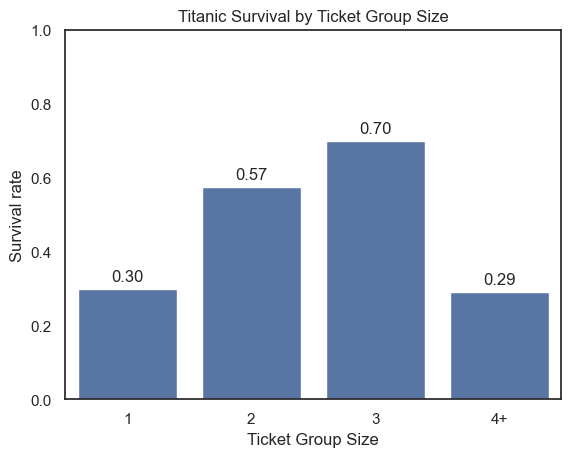

In [37]:
fig, ax = plt.subplots()
sns.set_theme(style="white")

percentages = table.div(table.sum(axis=1), axis=0)[1]
sns.barplot(x = percentages.index, y = percentages.values, ax = ax, errorbar=None)

ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival by Ticket Group Size")
ax.set_xlabel("Ticket Group Size")

for i, v in enumerate(percentages):
    ax.text(i, v + 0.02,f"{v:0.2f}", ha="center")

plt.show()


# Comparing the survival rate of ticket price

We will test if there is statistically significant dependence on ticket price, using the chi-square test

H0: Survival is independent of ticket price

Ha: Survival depends on ticket price

In [38]:
labels = ["veryCheap", "cheap", "normal", "expensive", "veryExpensive"]
bins = [-0.5, 8, 15, 30, 70, 550 ]

data["FareGroup"] = pd.cut(data["Fare"], bins = bins, labels = labels)

table = pd.crosstab(data["FareGroup"], data["Survived"])

chi2, p, dof, expected = chi2_contingency(table)


We get p = 3.011758167475959e-20, p < 0.05 meaning we can say that H0 is not correct and survival depends on ticket price, we can clearly see this by looking at the survival rates by age group in the barplot below

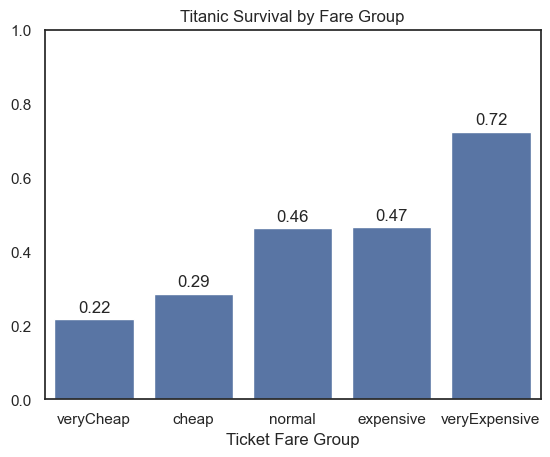

In [39]:
fig,ax = plt.subplots()

percentages = table.div(table.sum(axis=1), axis=0)[1]
sns.barplot(x = percentages.index, y = percentages.values, ax = ax, errorbar=None)

ax.set_label("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival by Fare Group")
ax.set_xlabel("Ticket Fare Group")

for i, v in enumerate(percentages):
    ax.text(i, v + 0.02,f"{v:0.2f}", ha="center")

plt.show()


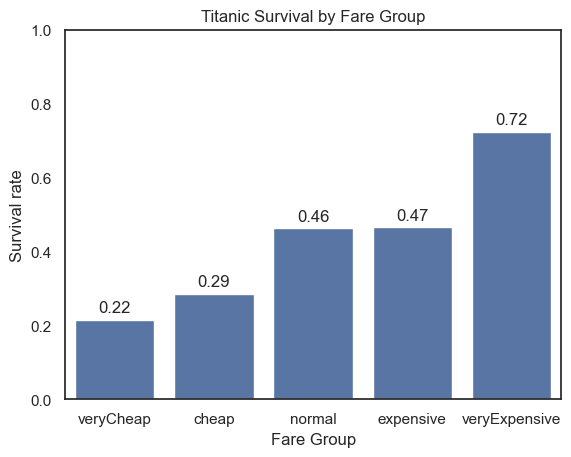

In [40]:
fig, ax = plt.subplots()

sns.barplot(x = data["FareGroup"], y = data["Survived"], ax = ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival by Fare Group")
ax.set_xlabel("Fare Group")

percentages = table.div(table.sum(axis=1), axis=0)[1]
for i, v in enumerate(percentages):
    ax.text(i, v + 0.02, f"{v:0.2f}", ha="center")

plt.show()


# Comparing the survival rate of ticket prefix starting letter

We will test if there is statistically significant dependence on ticket prefix, using the chi-square test

H0: Survival is independent of ticket prefix

Ha: Survival depends on ticket prefix

In [41]:
data["TicketPrefix"] = data["Ticket"].str.replace(r"\d+", "", regex=True).str.strip()
data["TicketPrefix"] = data["TicketPrefix"].replace("", "NONE")

def group_ticket_prefix(prefix):
    if prefix == "NONE":
        return "NONE"
    elif prefix.startswith("A"):
        return "A"
    elif prefix.startswith("C"):
        return "C"
    elif prefix.startswith("F"):
        return "F"
    elif prefix.startswith("P"):
        return "P"
    elif prefix.startswith("S"):
        return "S"
    elif prefix.startswith("W"):
        return "W"
    else:
        return "Other"


data["TicketPrefixGroup"] = data["TicketPrefix"].apply(group_ticket_prefix)
data["TicketPrefixGroup"] = data["TicketPrefixGroup"].apply(lambda x: "Other" if x == "F" or x =="W" else x)

table = pd.crosstab(data["TicketPrefixGroup"], data["Survived"])
chi2, p, dof, expected = chi2_contingency(table)


We get p = 3.2510551872532767e-06, p < 0.05 meaning we can say that H0 is not correct and survival depends on ticket price, we can clearly see this by looking at the survival rates by age group in the barplot below

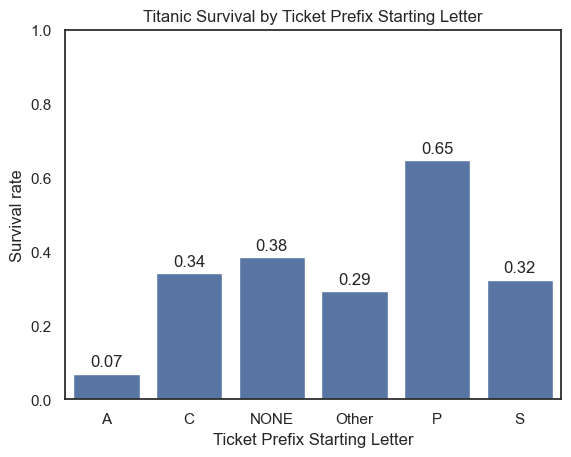

In [42]:
fig, ax = plt.subplots()

percentages = table.div(table.sum(axis=1), axis=0)[1]

sns.barplot(x = percentages.index, y = percentages.values, ax = ax, errorbar=None)
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)
ax.set_title("Titanic Survival by Ticket Prefix Starting Letter")
ax.set_xlabel("Ticket Prefix Starting Letter")

for i, v in enumerate(percentages):
    ax.text(i, v + 0.02, f"{v:0.2f}", ha="center")

plt.show()

# Analyzing the most important parameters

To get the most important parameters we need to look at their p-value. The smaller the p-value the larger the importance of the parameters

In [43]:
params = {
    "gender": 4.196e-78,
    "age": 0.00011219891528134224,
    "sib/sp": 5.9050699295674066e-08,
    "par/ch": 5.083693915431411e-06,
    "fam size": 6.522919536640473e-17,
    "ticket class": 4.549251711298793e-23,
    "ticket group size": 2.5257675410343483e-16,
    "ticket price": 3.011758167475959e-20,
    "ticket prefix": 3.2510551872532767e-06
}
params = dict(sorted(params.items(),key =lambda x: x[1]))
print(f"The importance of the parameters is as follows:")
for i,param in enumerate(params.keys()):
    print(f"{i+1} - {param}")

The importance of the parameters is as follows:
1 - gender
2 - ticket class
3 - ticket price
4 - fam size
5 - ticket group size
6 - sib/sp
7 - ticket prefix
8 - par/ch
9 - age


# Save data as csv file

In [44]:
data.to_csv("data/titanic_processed.csv", index=False)